In [54]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

Зашумить изображение

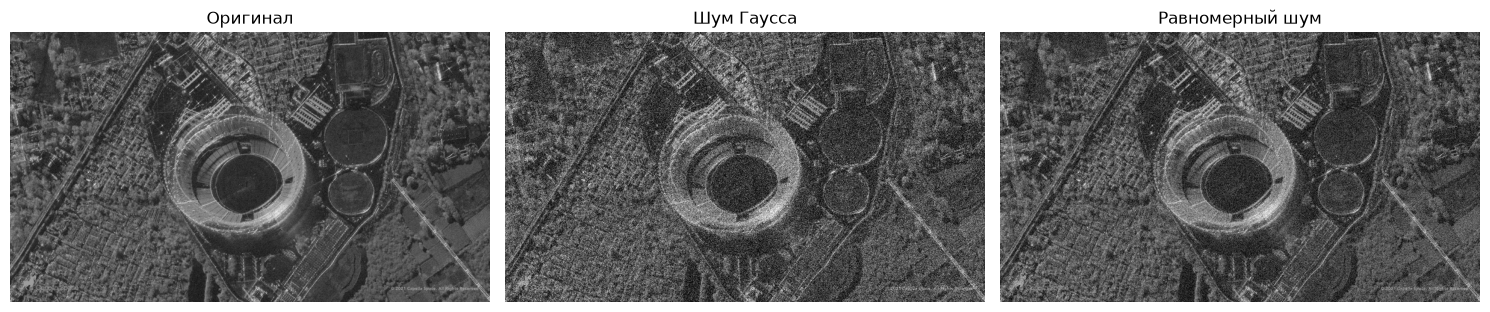

In [58]:
image = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)

mean, stddev = 0, 50
noise_gauss = np.zeros(image.shape, np.float32)
cv2.randn(noise_gauss, mean, stddev)
noise_gauss_image = np.clip(
    image.astype(np.float32) + noise_gauss, 0, 255
).astype(np.uint8)

low, high = -50, 50
noise_uniform = np.random.uniform(low, high, image.shape).astype(np.float32)
noise_uniform_image = np.clip(
    image.astype(np.float32) + noise_uniform, 0, 255
).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(image, cmap='gray'); plt.title('Оригинал'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(noise_gauss_image, cmap='gray'); plt.title('Шум Гаусса'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(noise_uniform_image, cmap='gray'); plt.title('Равномерный шум'); plt.axis('off')
plt.tight_layout()
plt.show()

Тест фильтров

Результаты:
Гаусса 3x3 сигма 0: MSE=378.79, SSIM=0.5190
Гаусса 5x5 сигма 0: MSE=285.21, SSIM=0.5626
Гаусса 7x7 сигма 0: MSE=264.94, SSIM=0.5599
Гаусса 3x3 сигма 1: MSE=357.02, SSIM=0.5275
Гаусса 5x5 сигма 1: MSE=293.53, SSIM=0.5598
Гаусса 7x7 сигма 1: MSE=289.25, SSIM=0.5617
Гаусса 3x3 сигма 2: MSE=346.90, SSIM=0.5215
Гаусса 5x5 сигма 2: MSE=278.66, SSIM=0.5392
Гаусса 7x7 сигма 2: MSE=279.52, SSIM=0.5258
Медианный 3x3: MSE=523.66, SSIM=0.4315
Медианный 5x5: MSE=359.96, SSIM=0.4535
Медианный 7x7: MSE=349.32, SSIM=0.4251
Билатериальный d=9 сигма 25: MSE=1546.21, SSIM=0.2657
Билатериальный d=9 сигма 75: MSE=404.52, SSIM=0.4606
Билатериальный d=15 сигма 100: MSE=356.87, SSIM=0.4429
Нелокальных средних h=10: MSE=2144.19, SSIM=0.2291
Нелокальных средних h=20: MSE=2112.43, SSIM=0.2308
Нелокальных средних h=30: MSE=587.24, SSIM=0.4211


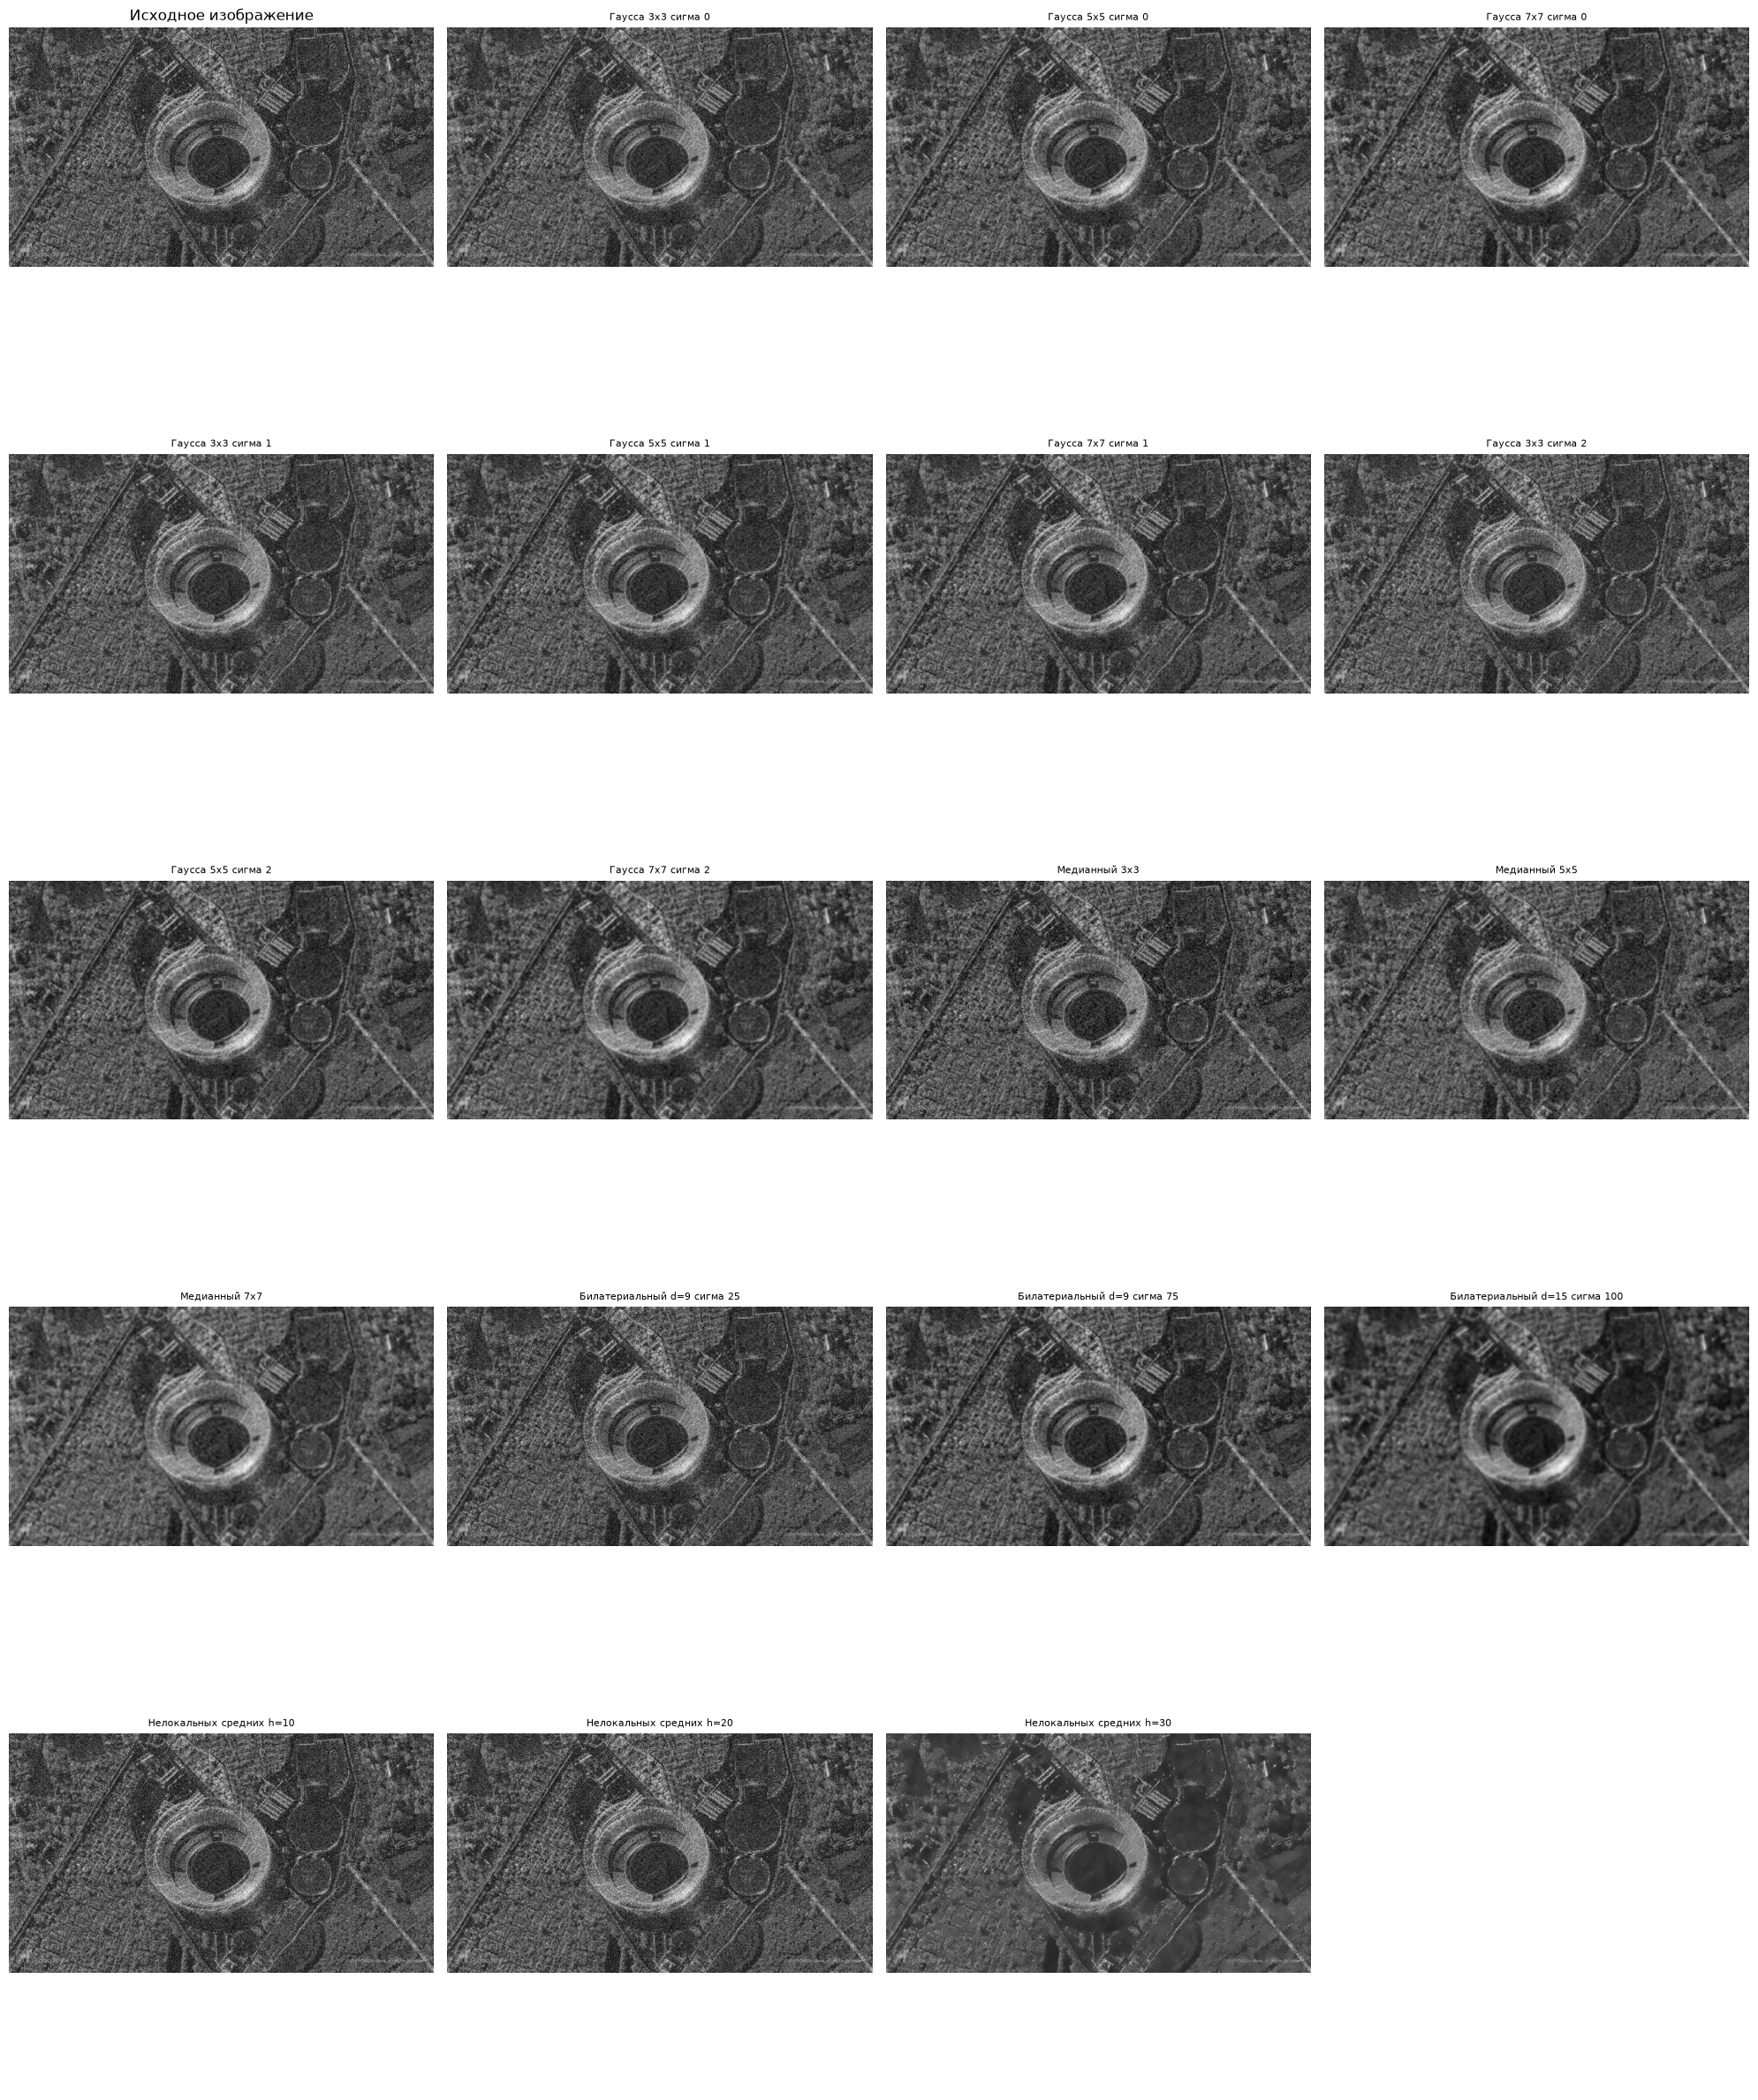

In [59]:
def filter_test(noisy_image, clean_image):
    filters_to_test = [
        ('Гаусса 3x3 сигма 0', cv2.GaussianBlur(noisy_image, (3, 3), 0)),
        ('Гаусса 5x5 сигма 0', cv2.GaussianBlur(noisy_image, (5, 5), 0)),
        ('Гаусса 7x7 сигма 0', cv2.GaussianBlur(noisy_image, (7, 7), 0)),
        ('Гаусса 3x3 сигма 1', cv2.GaussianBlur(noisy_image, (3, 3), 1)),
        ('Гаусса 5x5 сигма 1', cv2.GaussianBlur(noisy_image, (5, 5), 1)),
        ('Гаусса 7x7 сигма 1', cv2.GaussianBlur(noisy_image, (7, 7), 1)),
        ('Гаусса 3x3 сигма 2', cv2.GaussianBlur(noisy_image, (3, 3), 2)),
        ('Гаусса 5x5 сигма 2', cv2.GaussianBlur(noisy_image, (5, 5), 2)),
        ('Гаусса 7x7 сигма 2', cv2.GaussianBlur(noisy_image, (7, 7), 2)),
        
        ('Медианный 3x3', cv2.medianBlur(noisy_image, 3)),
        ('Медианный 5x5', cv2.medianBlur(noisy_image, 5)),
        ('Медианный 7x7', cv2.medianBlur(noisy_image, 7)),
        
        ('Билатериальный d=9 сигма 25', cv2.bilateralFilter(noisy_image, 9, 25, 25)),
        ('Билатериальный d=9 сигма 75', cv2.bilateralFilter(noisy_image, 9, 75, 75)),
        ('Билатериальный d=15 сигма 100', cv2.bilateralFilter(noisy_image, 15, 100, 100)),
        
        ('Нелокальных средних h=10', cv2.fastNlMeansDenoising(noisy_image, None, 10)),
        ('Нелокальных средних h=20', cv2.fastNlMeansDenoising(noisy_image, None, 20)),
        ('Нелокальных средних h=30', cv2.fastNlMeansDenoising(noisy_image, None, 30))
    ]
    results = {}

    print("Результаты:")
    
    for filter_name, filtered_image in filters_to_test:
        mse = mean_squared_error(clean_image, filtered_image)
        ssim = structural_similarity(clean_image, filtered_image)
        
        print(f"{filter_name}: MSE={mse:.2f}, SSIM={ssim:.4f}")
        
        results[filter_name] = {
            'image': filtered_image,
            'mse': mse,
            'ssim': ssim
        }
    return results

def visualize(noisy_image, results):
    n_filters = len(results)
    n_cols = 4
    n_rows = (n_filters + n_cols) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten()
    
    axes[0].imshow(noisy_image, cmap='gray')
    axes[0].set_title('Исходное изображение')
    axes[0].axis('off')
    
    for idx, (filter_name, result) in enumerate(results.items(), 1):
        if idx < len(axes):
            axes[idx].imshow(result['image'], cmap='gray')
            axes[idx].set_title(f'{filter_name}', fontsize=8)
            axes[idx].axis('off')
    
    for idx in range(len(results) + 1, len(axes)):
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()

results = filter_test(noise_gauss_image, image)
visualize(noise_gauss_image, results)

Поиск лучшего

Лучший фильтр по MSE:
  Название: Гаусса 7x7 сигма 0
  MSE: 264.94
  SSIM: 0.5599

Лучший фильтр по SSIM:
  Название: Гаусса 5x5 сигма 0
  MSE: 285.21
  SSIM: 0.5626


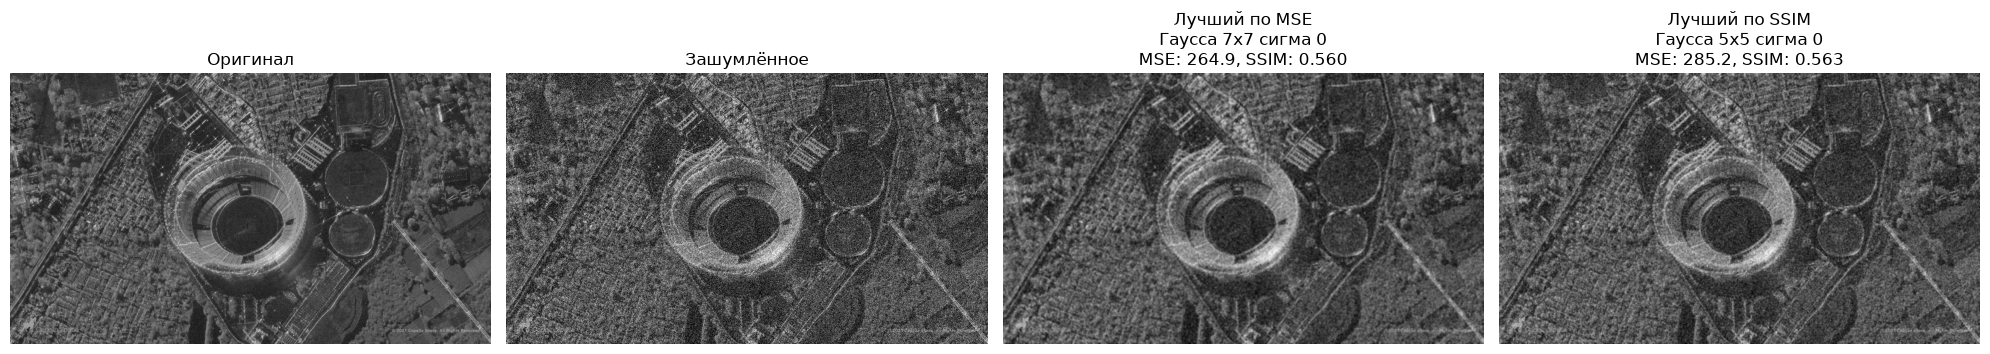

In [68]:
def find_best_filter(results, m):
    best = None
    for name, res in results.items():
        mse, ssim = res['mse'], res['ssim']

        if best is None:
            better = True
        elif m == 'mse':
            better = (mse < best['mse']) or (
                abs(mse - best['mse']) < 1e-9 and ssim > best['ssim']
            )
        else:
            better = (ssim > best['ssim']) or (
                abs(ssim - best['ssim']) < 1e-9 and mse < best['mse']
            )

        if better:
            best = {'name': name, 'mse': mse, 'ssim': ssim}

    return best


best_mse  = find_best_filter(results, 'mse')
best_ssim = find_best_filter(results, 'ssim')

print("Лучший фильтр по MSE:")
print(f"  Название: {best_mse['name']}")
print(f"  MSE: {best_mse['mse']:.2f}")
print(f"  SSIM: {best_mse['ssim']:.4f}")

print("\nЛучший фильтр по SSIM:")
print(f"  Название: {best_ssim['name']}")
print(f"  MSE: {best_ssim['mse']:.2f}")
print(f"  SSIM: {best_ssim['ssim']:.4f}")

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(noise_gauss_image, cmap='gray')
plt.title('Зашумлённое')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(results[best_mse['name']]['image'], cmap='gray')
plt.title(f"Лучший по MSE\n{best_mse['name']}\nMSE: {best_mse['mse']:.1f}, SSIM: {best_mse['ssim']:.3f}")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(results[best_ssim['name']]['image'], cmap='gray')
plt.title(f"Лучший по SSIM\n{best_ssim['name']}\nMSE: {best_ssim['mse']:.1f}, SSIM: {best_ssim['ssim']:.3f}")
plt.axis('off')

plt.tight_layout()
plt.show()